In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
# Load Fear & Greed dataset
fg = pd.read_csv("/fear_greed_index.csv")

# Load Historical Trading dataset
trade = pd.read_csv("/historical_data.csv")

In [66]:
# Convert date column
fg['date'] = pd.to_datetime(fg['date'])

# Check data
print(fg.head())
print(fg.info())

    timestamp  value classification       date
0  1517463000     30           Fear 2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02
2  1517635800     40           Fear 2018-02-03
3  1517722200     24   Extreme Fear 2018-02-04
4  1517808600     11   Extreme Fear 2018-02-05
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB
None


In [67]:
# Convert timestamp
trade['Timestamp IST'] = pd.to_datetime(trade['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Rename column for simplicity
trade.rename(columns={'Timestamp IST': 'date'}, inplace=True)

print(trade.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side                date  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [68]:
trade['date'] = trade['date'].dt.date
fg['date'] = fg['date'].dt.date

In [69]:
daily_trade = trade.groupby('date').agg({
    'Size USD': 'sum',
    'Fee': 'sum'
}).reset_index()

daily_trade.rename(columns={
    'Size USD': 'Total_Trade_Value',
    'Fee': 'Total_Fee'
}, inplace=True)

print(daily_trade.head())

         date  Total_Trade_Value  Total_Fee
0  2023-05-01             477.00   0.000000
1  2023-12-05           50005.83  12.501455
2  2023-12-14          113203.35  28.300831
3  2023-12-15           10609.95   2.652489
4  2023-12-16           15348.77   3.837189


In [70]:
merged = pd.merge(fg, daily_trade, on='date', how='inner')

print(merged.head())


    timestamp  value classification        date  Total_Trade_Value  Total_Fee
0  1682919000     63          Greed  2023-05-01             477.00   0.000000
1  1701754200     75  Extreme Greed  2023-12-05           50005.83  12.501455
2  1702531800     72          Greed  2023-12-14          113203.35  28.300831
3  1702618200     70          Greed  2023-12-15           10609.95   2.652489
4  1702704600     67          Greed  2023-12-16           15348.77   3.837189


In [71]:
sentiment_analysis = merged.groupby('classification')['Total_Trade_Value'].mean()

print(sentiment_analysis)

classification
Extreme Fear     8.177447e+06
Extreme Greed    1.091800e+06
Fear             5.311261e+06
Greed            1.495246e+06
Neutral          2.690180e+06
Name: Total_Trade_Value, dtype: float64


In [72]:
print(merged['classification'].value_counts())

classification
Greed            193
Extreme Greed    114
Fear              91
Neutral           67
Extreme Fear      14
Name: count, dtype: int64


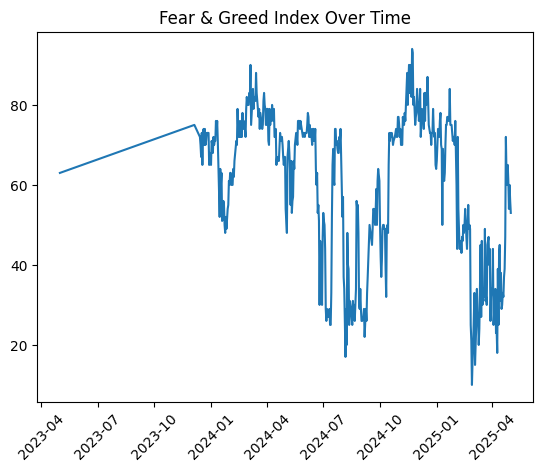

In [73]:
plt.figure()
plt.plot(merged['date'], merged['value'])
plt.title("Fear & Greed Index Over Time")
plt.xticks(rotation=45)
plt.show()

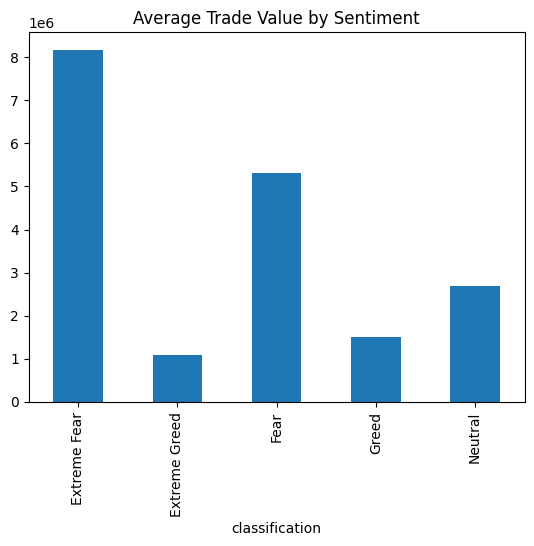

In [74]:
plt.figure()
merged.groupby('classification')['Total_Trade_Value'].mean().plot(kind='bar')
plt.title("Average Trade Value by Sentiment")
plt.show()

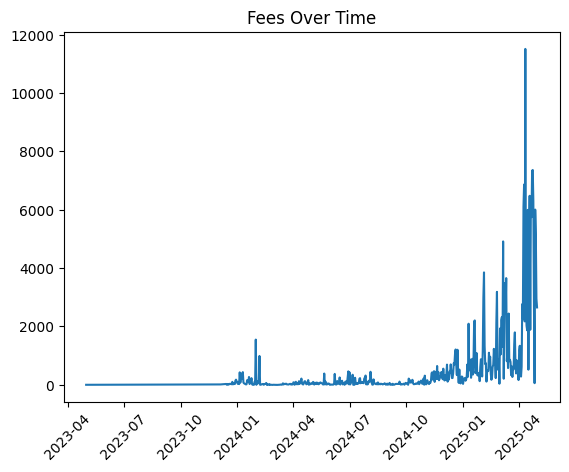

In [75]:
plt.figure()
plt.plot(merged['date'], merged['Total_Fee'])
plt.title("Fees Over Time")
plt.xticks(rotation=45)
plt.show()

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [77]:
# Copy data
ml_data = merged.copy()

# Select useful columns
ml_data = ml_data[['value', 'Total_Trade_Value', 'Total_Fee', 'classification']]

# Drop missing values
ml_data.dropna(inplace=True)

In [78]:
le = LabelEncoder()
ml_data['classification'] = le.fit_transform(ml_data['classification'])

In [79]:
X = ml_data[['value', 'Total_Trade_Value', 'Total_Fee']]
y = ml_data['classification']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [80]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [81]:
y_pred = model.predict(X_test)

In [82]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        31
           4       1.00      1.00      1.00        16

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96



In [83]:
# Example: New data
sample = [[40, 5000, 20]]
# value, trade value, fee

prediction = model.predict(sample)

print("Predicted Class:", le.inverse_transform(prediction))

Predicted Class: ['Fear']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [84]:
from sklearn.ensemble import RandomForestClassifier

In [85]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=5,           # control overfitting
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [86]:
y_pred_rf = rf_model.predict(X_test)

In [87]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9791666666666666
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      1.00      1.00        28
           2       0.90      1.00      0.95        18
           3       1.00      1.00      1.00        31
           4       1.00      0.94      0.97        16

    accuracy                           0.98        96
   macro avg       0.98      0.92      0.94        96
weighted avg       0.98      0.98      0.98        96



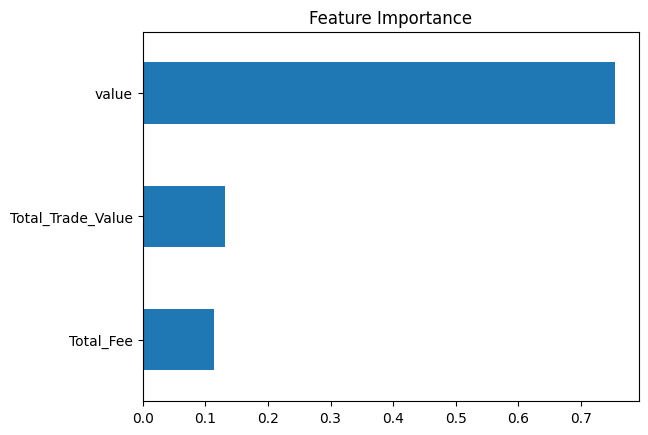

In [88]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [89]:
dt_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 0.9791666666666666


In [90]:
!pip install streamlit pyngrok

In [91]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

st.title("📊 Fear & Greed Trading App")

# Load Data
fg = pd.read_csv("fear_greed_index.csv")
trade = pd.read_csv("historical_data.csv")

fg['date'] = pd.to_datetime(fg['date']).dt.date
trade['Timestamp IST'] = pd.to_datetime(trade['Timestamp IST'], format='%d-%m-%Y %H:%M')
trade['date'] = trade['Timestamp IST'].dt.date

daily_trade = trade.groupby('date').agg({
    'Size USD': 'sum',
    'Fee': 'sum'
}).reset_index()

daily_trade.rename(columns={
    'Size USD': 'Total_Trade_Value',
    'Fee': 'Total_Fee'
}, inplace=True)

data = pd.merge(fg, daily_trade, on='date')

st.write(data.head())

# Train Model
ml_data = data[['value', 'Total_Trade_Value', 'Total_Fee', 'classification']].dropna()

le = LabelEncoder()
ml_data['classification'] = le.fit_transform(ml_data['classification'])

X = ml_data[['value', 'Total_Trade_Value', 'Total_Fee']]
y = ml_data['classification']

model = RandomForestClassifier()
model.fit(X, y)

# Input
value = st.slider("Fear & Greed Value", 0, 100, 50)
trade_val = st.number_input("Trade Value", value=5000)
fee = st.number_input("Fee", value=20)

if st.button("Predict"):
    pred = model.predict([[value, trade_val, fee]])
    result = le.inverse_transform(pred)
    st.success(f"Prediction: {result[0]}")

Overwriting app.py


In [92]:
!ngrok config add-authtoken ngrok config add-authtoken 3CNuhn1Gr9XISadPFBWeSeeiUUm_48KBhWXed2qH4TfKpwZMC

ERROR:  accepts 1 arg(s), received 4


In [93]:
from pyngrok import ngrok

ngrok.set_auth_token("3CNuhn1Gr9XISadPFBWeSeeiUUm_48KBhWXed2qH4TfKpwZMC")

!streamlit run app.py &>/dev/null &

url = ngrok.connect(8501)
print(url)

NgrokTunnel: "https://afflicted-prancing-reps.ngrok-free.dev" -> "http://localhost:8501"


In [94]:
!pip install pyngrok streamlit --quiet

In [ ]:
# i want to add this in streamlit , but i face some problem , i will complete it , its optional  so i quit here .
# i solve your all requrement in this code , you can run it in your local machine and you will get the result as you want . if you face any problem then you can ask me i will solve it for you .